# Affluence: observed Dubai rents per cell, and what they do to the calls

Bedashing is a premium salon, so a woman in Emirates Hills and one in International City should not
count the same. This notebook builds an **affluence index per ~2 km cell** from free data and shows
how it weights demand. The method lives in `scripts/build_affluence.py` (its docstring); the
weighting in `src.market.affluence_weight`; this notebook has **no model logic of its own**: it
calls those and `src.baseline.run`, and plots what comes back.

- **Index:** median annual household rent (AED) of DLD Ejari contracts registered 2026-07-10 to
  2026-10-09, per DLD area, mapped to cells. Housing cost, not income or salon spend.
- **Weight:** `(cell rent / women-weighted median rent) ^ elasticity`, clipped to 0.25-4 and
  rescaled so the women-weighted mean over observed cells is 1. Elasticity off 0 / **medium 0.5** /
  strong 1 (`affluence_elasticity` in `data/scenarios/baseline.yaml`). Cells without an observed rent
  weigh 1: **neutral, not average-by-evidence**.
- **Addressable women** = women 15+ x weight. The scorecard's demand signal and the growth size test
  read it; `catchment_women` and an area's `women` stay raw.

Data: `data/raw/dld/rents-2026-10-10.csv` (downloaded by hand: the DLD site is captcha-gated and
serves at most 3 months; gitignored), `data/seed/v3/dubai_rents_by_area.csv`,
`data/seed/v3/cell_affluence.csv`, `data/seed/v3/cell_built_form.csv` (GHSL 2018).
Sources: `data/seed/v3/SOURCES.md`, "Affluence".

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import glob
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.patches import Rectangle

from scripts import build_affluence as BA
from src.baseline import run
from src.config import load_baseline_assumptions
from src.data_v3 import LEVELS, load_v3
from src.market import affluence_weight, weighted_median, women_15plus
from src.models import Levels

pd.set_option("display.width", 160)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.2, "grid.color": "#888", "axes.edgecolor": "#999", "font.size": 9})
BLUE, ORANGE, AQUA, YELLOW, GREY, RED = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9e9e9e", "#d64545"
NAME = {"low": "off", "medium": "medium", "high": "strong"}

A = load_baseline_assumptions(ROOT / "data/scenarios/baseline.yaml")
v3 = load_v3()
cells = v3.cells
women = women_15plus(cells, v3.emirates, A.worker_housing_female_share["medium"])
V3 = ROOT / "data/seed/v3"
aff = pd.read_csv(V3 / "cell_affluence.csv").set_index("cell_id")
form = pd.read_csv(V3 / "cell_built_form.csv").set_index("cell_id")
print(f"{len(cells)} cells; affluence source: {aff.source.value_counts().to_dict()}; elasticity {A.affluence_elasticity}")

2373 cells; affluence source: {'none': 2132, 'observed': 241}; elasticity {'low': 0.0, 'medium': 0.5, 'high': 1.0}


## 1. The DLD rents and the filters

One row per Ejari contract. We keep **residential contracts for one household unit**: a flat, villa
or studio, one property per contract, a positive annual amount. Labour camps, staff accommodation,
shops and bulk leases of many units are left out: they aren't a household's rent.

311,146 contracts registered 2026-07-10 to 2026-10-09, 189 DLD areas


filter,contracts left
all contracts,311146
residential,251430
flat / villa / studio,219465
one property per contract,207240
annual amount > 0,207240


residential sub-types dropped: {'Labor Camps': 30146, 'Complex Villas': 1292, 'Staff Accommodation': 437, 'Building': 35, 'Arabian House': 14, 'Penthouse': 9, 'Mezzanine': 7, 'Hotel': 3}


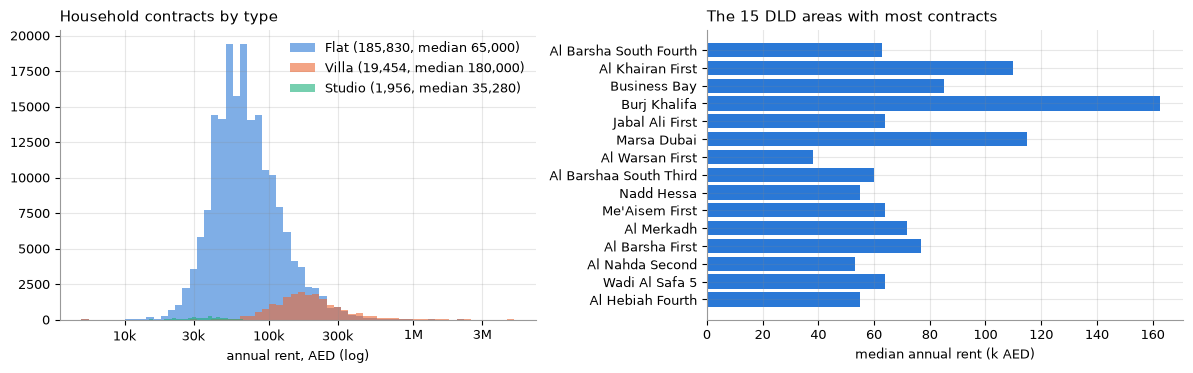

recomputed areas equal the committed dubai_rents_by_area.csv: True


In [2]:
raw = pd.concat(pd.read_csv(f, encoding="utf-8-sig", low_memory=False) for f in sorted(glob.glob(str(ROOT / "data/raw/dld/rents-*.csv"))))
reg = pd.to_datetime(raw.REGISTRATION_DATE)
print(f"{len(raw):,} contracts registered {reg.min():%Y-%m-%d} to {reg.max():%Y-%m-%d}, {raw.AREA_EN.nunique()} DLD areas")
sub = raw.PROP_SUB_TYPE_EN.astype(str).str.strip()
steps = [("all contracts", pd.Series(True, raw.index)),
         ("residential", raw.USAGE_EN == "Residential"),
         ("flat / villa / studio", sub.isin(BA.HOUSEHOLD)),
         ("one property per contract", raw.TOTAL_PROPERTIES == 1),
         ("annual amount > 0", raw.ANNUAL_AMOUNT > 0)]
keep, funnel = pd.Series(True, raw.index), []
for name, m in steps:
    keep &= m
    funnel.append({"filter": name, "contracts left": int(keep.sum())})
display(pd.DataFrame(funnel).style.hide(axis="index"))
kept = raw[keep]
print("residential sub-types dropped:", raw[(raw.USAGE_EN == "Residential") & ~sub.isin(BA.HOUSEHOLD)].PROP_SUB_TYPE_EN.value_counts().head(8).to_dict())
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for s, c in (("Flat", BLUE), ("Villa", ORANGE), ("Studio", AQUA)):
    x = kept[kept.PROP_SUB_TYPE_EN.str.strip() == s].ANNUAL_AMOUNT
    axes[0].hist(np.log10(x.clip(5_000, 5_000_000)), bins=60, alpha=0.6, color=c, label=f"{s} ({len(x):,}, median {x.median():,.0f})")
axes[0].set_xticks(np.log10([1e4, 3e4, 1e5, 3e5, 1e6, 3e6]), ["10k", "30k", "100k", "300k", "1M", "3M"])
axes[0].set_xlabel("annual rent, AED (log)"); axes[0].legend(frameon=False); axes[0].set_title("Household contracts by type", loc="left")
areas = BA.locate(BA.area_rents(raw))
top = areas.sort_values("contracts", ascending=False).head(15)[::-1]
axes[1].barh(top.area, top.median_rent / 1000, color=BLUE); axes[1].set_xlabel("median annual rent (k AED)")
axes[1].set_title("The 15 DLD areas with most contracts", loc="left")
plt.tight_layout(); plt.show()
committed = pd.read_csv(V3 / "dubai_rents_by_area.csv")
print("recomputed areas equal the committed dubai_rents_by_area.csv:",
      np.allclose(areas.median_rent, committed.median_rent) and (areas.area == committed.area).all())

## 2. DLD areas to points

DLD names its areas by the land registry ("Marsa Dubai", "Al Barshaa South Fourth"), not always by
the name people use. Each area is matched by normalised name (spelling table, ordinals as numbers)
to, in order: an OSM admin-10 polygon centroid, an OSM place point in Dubai, the centre of the
`cells.csv` cells carrying that name, the same name without its trailing number, or a hand-written
alias.

In [3]:
m = areas.groupby("match").agg(areas=("area", "size"), contracts=("contracts", "sum"))
m["share of contracts"] = (m.contracts / m.contracts.sum()).round(3)
display(m.sort_values("contracts", ascending=False))
located = areas.match != "unmatched"
print(f"{located.sum()}/{len(areas)} DLD areas located, {areas.contracts[located].sum() / areas.contracts.sum():.1%} of contracts")
display(pd.DataFrame([{"DLD area": k, "located as": n, "lat": la, "lng": ln, "contracts": int(areas.set_index("area").contracts.get(k, 0))}
                      for k, (la, ln, n) in BA.ALIASES.items()]).style.hide(axis="index").set_caption("Hand-written aliases"))
print("unmatched:", areas[~located].sort_values("contracts", ascending=False)[["area", "contracts"]].to_dict("records"))
print(f"areas under MIN_CONTRACTS = {BA.MIN_CONTRACTS} (left out of the cells): {(located & (areas.contracts < BA.MIN_CONTRACTS)).sum()}, "
      f"{areas.contracts[located & (areas.contracts < BA.MIN_CONTRACTS)].sum()} contracts")

,areas,contracts,share of contracts
match,,,
osm_place,153,171206,0.826
alias,7,27628,0.133
cells_named,3,3321,0.016
osm_base_name,5,3051,0.015
unmatched,5,2034,0.010


168/173 DLD areas located, 99.0% of contracts


DLD area,located as,lat,lng,contracts
Al Khairan First,Dubai Creek Harbour,25.200500,55.352000,10194
Marsa Dubai,Dubai Marina,25.080500,55.140300,6971
Burj Khalifa,Downtown Dubai,25.196000,55.278000,8436
Palm Jumeirah,Palm Jumeirah,25.112400,55.139000,1421
Madinat Dubai Almelaheyah,Mina Rashid,25.264000,55.277000,568
Island 2,Jumeirah Islands,25.044000,55.160000,27
Hatta,Hatta,24.800000,56.128000,11


unmatched: [{'area': 'Al Suq Al Kabeer', 'contracts': 1546}, {'area': 'Rega Al Buteen', 'contracts': 224}, {'area': 'Al Dhagaya', 'contracts': 211}, {'area': 'Ras Al Khor Industrial Second', 'contracts': 32}, {'area': 'Al Yufrah 3', 'contracts': 21}]
areas under MIN_CONTRACTS = 20 (left out of the cells): 23, 173 contracts


## 3. Observed rent per cell

A Dubai cell's rent is the contract-weighted median of the area medians whose point lies inside it;
with none inside, the nearest area point within 2.5 km. Coloured cells below have an observed rent;
the rest of Dubai (desert, industrial, or no area point near) has none and is weighted neutral.

241 cells observed; rent median 75,000, women-weighted median 80,000, range 21,600-710,000 AED/yr; 81% of Dubai's women live in them


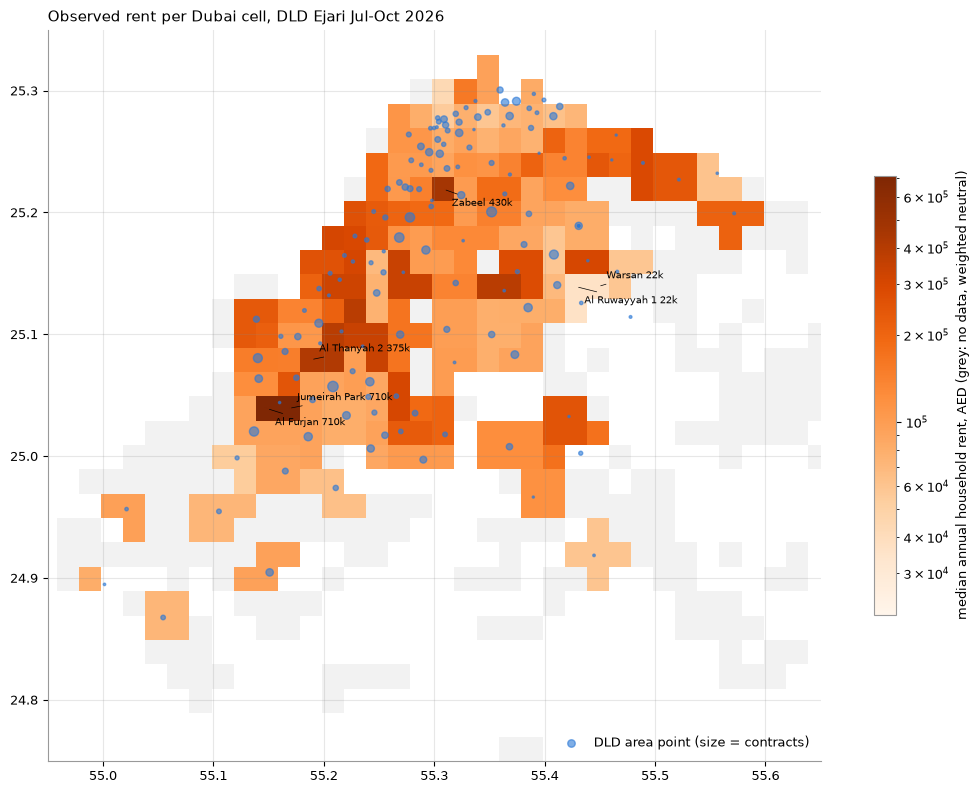

In [4]:
obs = aff.rent_observed.dropna()
print(f"{len(obs)} cells observed; rent median {obs.median():,.0f}, women-weighted median "
      f"{weighted_median(obs, women[obs.index]):,.0f}, range {obs.min():,.0f}-{obs.max():,.0f} AED/yr; "
      f"{women[obs.index].sum() / women[cells.emirate == 'Dubai'].sum():.0%} of Dubai's women live in them")
dub = cells[cells.emirate == "Dubai"]
lo, hi = np.log(obs.min()), np.log(obs.max())
cmap = plt.get_cmap("Oranges")
fig, ax = plt.subplots(figsize=(11, 8))
for cid, c in dub.iterrows():
    r = aff.rent_observed.get(cid)
    face = cmap(0.15 + 0.85 * (np.log(r) - lo) / (hi - lo)) if r == r else "#f2f2f2"
    ax.add_patch(Rectangle((c.west, c.south), c.east - c.west, c.north - c.south, color=face, lw=0))
pts = areas[located & (areas.contracts >= BA.MIN_CONTRACTS)]
ax.scatter(pts.lng, pts.lat, s=np.sqrt(pts.contracts) / 2, color=BLUE, alpha=0.6, label="DLD area point (size = contracts)")
for i, cid in enumerate(list(obs.nlargest(4).index) + list(obs.nsmallest(2).index)):
    c = cells.loc[cid]
    ax.annotate(f"{c['name']} {obs[cid] / 1000:.0f}k", (c.lng, c.lat), fontsize=7, xytext=(6, 6 if i % 2 else -12),
                textcoords="offset points", arrowprops={"arrowstyle": "-", "lw": 0.5})
ax.set_xlim(54.95, 55.65); ax.set_ylim(24.75, 25.35); ax.set_aspect(1 / np.cos(np.radians(25)))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.matplotlib.colors.LogNorm(obs.min(), obs.max()))
plt.colorbar(sm, ax=ax, shrink=0.6, label="median annual household rent, AED (grey: no data, weighted neutral)")
ax.legend(frameon=False, loc="lower right"); ax.set_title("Observed rent per Dubai cell, DLD Ejari Jul-Oct 2026", loc="left")
plt.tight_layout(); plt.show()

## 4. Can built form stand in for rent outside Dubai? No.

The plan was to fit `log(rent) ~ built form` (GHSL 2018: residential share, villa share, tower share,
greenery, mean height) on the observed Dubai cells and predict every UAE cell. **Go/no-go: a
cross-validated R² of at least 0.3** (`MIN_R2`), cross-validated by name group so neighbouring cells
of one community never sit on both sides of a fold.

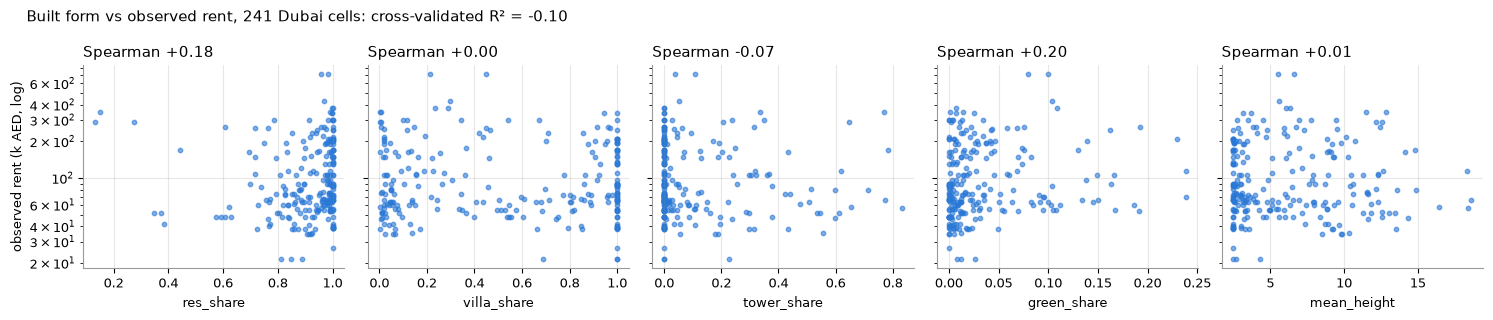

max |Spearman| = 0.20; CV R² = -0.10 (go needs >= 0.3): NO-GO, rent_predicted is kept in the CSV but not used
source counts in cell_affluence.csv: {'none': 2132, 'observed': 241}


In [5]:
train = form.loc[obs.index, BA.FEATURES].dropna()
y = obs[train.index]
beta, r2 = BA.fit(train, y, cells.loc[train.index, "name"])
rho = train.apply(lambda c: c.corr(np.log(y), method="spearman"))
fig, axes = plt.subplots(1, len(BA.FEATURES), figsize=(15, 3.2), sharey=True)
for ax, f in zip(axes, BA.FEATURES):
    ax.scatter(train[f], y / 1000, s=10, color=BLUE, alpha=0.6)
    ax.set_yscale("log"); ax.set_xlabel(f); ax.set_title(f"Spearman {rho[f]:+.2f}", loc="left")
axes[0].set_ylabel("observed rent (k AED, log)")
fig.suptitle(f"Built form vs observed rent, {len(train)} Dubai cells: cross-validated R² = {r2:.2f}", x=0.02, ha="left")
plt.tight_layout(); plt.show()
print(f"max |Spearman| = {rho.abs().max():.2f}; CV R² = {r2:.2f} (go needs >= {BA.MIN_R2}): "
      + ("proxy used" if r2 >= BA.MIN_R2 else "NO-GO, rent_predicted is kept in the CSV but not used"))
print("source counts in cell_affluence.csv:", aff.source.value_counts().to_dict())

**Why it fails.** The feature the plan leaned on, villa share, has a Spearman correlation with
rent of 0.01; mean height 0.01, tower share -0.07; the best are greenery and residential share at
about 0.2. Low-rise and towers each span cheap and dear communities, and 2018 built form misses
what has gone up since. A model that predicts worse than the mean (negative R²) is worse than no
adjustment, so **every cell outside the 241 observed Dubai cells is weighted neutral (1)**. That
includes every Abu Dhabi, Sharjah, Fujairah and RAK lounge and every growth area outside Dubai.

## 5. The weights at medium and strong

The weight is relative to the women-weighted median observed rent, so a median Dubai cell is near 1
before rescaling. Rescaling keeps the observed cells' women-weighted mean at exactly 1, so Dubai's
total addressable women equal its raw women in the observed cells: the weighting moves women
between Dubai cells, it doesn't add any.

,mean,std,min,10%,25%,50%,75%,90%,max,women-weighted mean,clipped cells
off (e = 0),1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0,0
medium (e = 0.5),0.97,0.36,0.44,0.62,0.71,0.82,1.22,1.50,2.53,1.0,0
strong (e = 1),0.96,0.68,0.18,0.35,0.47,0.63,1.38,2.07,2.68,1.0,9


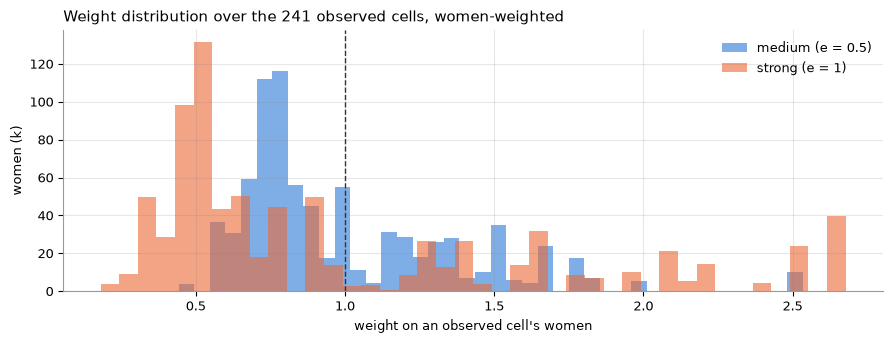

neutral (no rent) cells: 2132, holding 73% of the UAE's women


In [6]:
rent = cells.rent_observed
W = {lv: affluence_weight(rent, women, A.affluence_elasticity[lv]) for lv in LEVELS}
o = rent.notna()
q = pd.DataFrame({f"{NAME[lv]} (e = {A.affluence_elasticity[lv]:g})": W[lv][o].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
                  for lv in LEVELS}).T.drop(columns="count").round(2)
q["women-weighted mean"] = [round((W[lv][o] * women[o]).sum() / women[o].sum(), 6) for lv in LEVELS]
ratio = rent[o] / weighted_median(rent[o], women[o])
q["clipped cells"] = [int(((ratio ** A.affluence_elasticity[lv] < 0.25) | (ratio ** A.affluence_elasticity[lv] > 4)).sum()) for lv in LEVELS]
display(q)
fig, ax = plt.subplots(figsize=(9, 3.5))
for lv, c in (("medium", BLUE), ("high", ORANGE)):
    ax.hist(W[lv][o], bins=40, weights=women[o] / 1000, alpha=0.6, color=c, label=f"{NAME[lv]} (e = {A.affluence_elasticity[lv]:g})")
ax.axvline(1, color="#333", lw=1, ls="--"); ax.set_xlabel("weight on an observed cell's women"); ax.set_ylabel("women (k)")
ax.legend(frameon=False); ax.set_title("Weight distribution over the 241 observed cells, women-weighted", loc="left")
plt.tight_layout(); plt.show()
print(f"neutral (no rent) cells: {(~o).sum()}, holding {women[~o].sum() / women.sum():.0%} of the UAE's women")

## 6. What it does to the calls

The full pipeline (`src.baseline.run`) at affluence off / medium / strong, every other level at
medium. Off reproduces the model before rents exactly (`tests/features/test_lounges.py`).

In [7]:
R = {lv: run(Levels(affluence=lv)) for lv in LEVELS}
rows = []
for lv, r in R.items():
    c = Counter(d.action for d in r.decisions); g = Counter(d.action for d in r.area_decisions)
    rows.append({"affluence": f"{NAME[lv]} ({lv})", **{a: c[a] for a in ("PROTECT", "HOLD", "SHRINK")},
                 "low confidence": sum(d.confidence == "low" for d in r.decisions if d.action != "NOT SCORED"),
                 **{a: g[a] for a in ("GROW", "WATCH", "SKIP")}})
display(pd.DataFrame(rows).set_index("affluence"))
base_l = {d.branch_id: d for d in R["low"].decisions}
base_a = {d.area_id: d.action for d in R["low"].area_decisions}
for lv in ("medium", "high"):
    moved = [f"{d.branch_id} {base_l[d.branch_id].action} -> {d.action}" for d in R[lv].decisions if d.action != base_l[d.branch_id].action]
    amoved = [f"{d.area_id} {base_a[d.area_id]} -> {d.action}" for d in R[lv].area_decisions if d.action != base_a[d.area_id]]
    print(f"{NAME[lv]:>7}: lounge calls changed: {moved or 'none'}; area calls changed: {amoved or 'none'}")
F = {lv: pd.DataFrame([f.model_dump() for f in r.features]).set_index("branch_id") for lv, r in R.items()}
Dc = {lv: pd.DataFrame([d.model_dump() for d in r.decisions]).set_index("branch_id") for lv, r in R.items()}
t = F["medium"][["emirate", "catchment_women", "affluence_rent", "affluence_coverage"]].copy()
for lv in LEVELS:
    t[f"addressable {NAME[lv]}"] = F[lv].addressable_women
    t[f"composite {NAME[lv]}"] = Dc[lv].composite
t = t[t.affluence_coverage > 0].sort_values("affluence_rent", ascending=False)
t.round({"catchment_women": 0, "affluence_coverage": 2, **{f"addressable {NAME[lv]}": 0 for lv in LEVELS}})

,PROTECT,HOLD,SHRINK,low confidence,GROW,WATCH,SKIP
affluence,,,,,,,
off (low),3,13,7,10,4,37,539
medium (medium),3,13,7,10,5,36,539
strong (high),3,13,7,10,5,36,539


 medium: lounge calls changed: none; area calls changed: ['al-awir-dubai WATCH -> GROW']
 strong: lounge calls changed: none; area calls changed: ['al-awir-dubai WATCH -> GROW']


,emirate,catchment_women,affluence_rent,affluence_coverage,addressable off,composite off,addressable medium,composite medium,addressable strong,composite strong
branch_id,,,,,,,,,,
al-barsha,Dubai,272371.0,115000.0,0.99,272371.0,0.3664,320731.0,0.3664,360619.0,0.3664
city-walk,Dubai,259919.0,95550.0,1.00,259919.0,0.4074,278174.0,0.4074,298976.0,0.4074
mirdif-35,Dubai,241393.0,90000.0,0.93,241393.0,0.4974,231813.0,0.4974,223847.0,0.4974
nad-al-sheba,Dubai,247186.0,85000.0,0.97,247186.0,0.4345,238506.0,0.4345,231196.0,0.4345
jumeirah-park,Dubai,171595.0,66000.0,0.96,171595.0,0.4132,173297.0,0.4156,162614.0,0.4003
zawaya-walk,Sharjah,193382.0,58000.0,0.03,193382.0,0.5135,191565.0,0.5110,189989.0,0.5087


In [8]:
ar = {lv: pd.DataFrame([a.model_dump() for a in r.areas]).set_index("area_id") for lv, r in R.items()}
ad = {lv: pd.Series({d.area_id: d.action for d in r.area_decisions}) for lv, r in R.items()}
x = ar["medium"][ar["medium"].affluence_coverage > 0][["women", "affluence_rent", "affluence_coverage"]].copy()
for lv in LEVELS:
    x[f"addressable {NAME[lv]}"] = ar[lv].addressable_women
    x[f"call {NAME[lv]}"] = ad[lv]
print(f"{len(x)} growth areas have any observed rent; all are in Dubai: {set(ar['medium'].loc[x.index, 'emirate'])}")
x[x.women >= 5000].sort_values("women", ascending=False).round({"women": 0, "affluence_coverage": 2, **{f"addressable {NAME[lv]}": 0 for lv in LEVELS}})

43 growth areas have any observed rent; all are in Dubai: {'Dubai'}


,women,affluence_rent,affluence_coverage,addressable off,call off,addressable medium,call medium,addressable strong,call strong
area_id,,,,,,,,,
al-awir-dubai,19387.0,170000.0,0.38,19387.0,WATCH,20078.0,GROW,20663.0,GROW
al-lesaily-dubai,18812.0,38794.0,0.21,18812.0,WATCH,17231.0,WATCH,16191.0,WATCH
nakhlat-jumeira-dubai,8110.0,195000.0,0.66,8110.0,SKIP,9865.0,SKIP,11488.0,SKIP
hor-al-anz-dubai,7703.0,38000.0,1.00,7703.0,SKIP,4517.0,SKIP,2450.0,SKIP
dubai-investments-park-dubai,7522.0,42000.0,0.77,7522.0,WATCH,5306.0,WATCH,3775.0,WATCH
wadi-al-safa-3-dubai,7106.0,69500.0,0.68,7106.0,SKIP,6099.0,SKIP,5071.0,SKIP
al-mamzar-dubai,6724.0,66150.0,1.00,6724.0,SKIP,5202.0,SKIP,3723.0,SKIP
jabal-ali-industrial-2-dubai,6277.0,48000.0,0.76,6277.0,WATCH,4644.0,WATCH,3411.0,WATCH
madinat-hind-4-dubai,5992.0,90000.0,1.00,5992.0,WATCH,5407.0,WATCH,4513.0,WATCH


## 7. Examples

**al-barsha** (Dubai's biggest catchment, observed almost entirely) and **al-awir-dubai** (the only
call affluence moves). Cells are shaded by observed rent (grey: no data, weighted neutral).

In [9]:
from shapely.geometry import box, mapping
from scripts.spot_maps import points, shapes, show

def cellbox(cid, label):
    c = cells.loc[cid]
    r = c.rent_observed
    fill = [int(255 * v) for v in cmap(0.15 + 0.85 * (np.log(r) - lo) / (hi - lo))[:3]] + [150] if r == r else [158, 158, 158, 60]
    return {"type": "Feature", "geometry": mapping(box(c.west, c.south, c.east, c.north)), "properties": {"label": label, "fill": fill}}

def lab(cid, wt):
    r = cells.at[cid, "rent_observed"]
    return (f"{cells.at[cid, 'name']}: {women[cid]:,.0f} women, " + (f"rent {r:,.0f} AED/yr, weight {wt[cid]:.2f}" if r == r else "no rent, weight 1"))

f, d = F["medium"].loc["al-barsha"], Dc["medium"].loc["al-barsha"]
catch = v3.catchment[(v3.catchment.level == "medium") & (v3.catchment.branch_id == "al-barsha")].cell_id
display(Markdown(f"### al-barsha: {d.action} at composite {d.composite:.2f} at every affluence level\n"
                 f"{f.catchment_women:,.0f} women raw, {f.addressable_women:,.0f} addressable at medium "
                 f"({F['high'].loc['al-barsha'].addressable_women:,.0f} strong); catchment rent {f.affluence_rent:,.0f} AED/yr, "
                 f"{f.affluence_coverage:.0%} observed. Demand already scores 1 above 200k women, so weighting it up changes nothing; "
                 f"its call rests on capture and cannibalisation."))
display(show([shapes([cellbox(c, lab(c, W["medium"])) for c in catch], fill="properties.fill", line=(80, 80, 80)),
              points([{"lat": f.lat, "lng": f.lng, "label": "al-barsha", "r": 300}], (20, 20, 20))], f.lat, f.lng, zoom=10.5))

a = ar["medium"].loc["al-awir-dubai"]
display(Markdown(f"### al-awir-dubai: {ad['low']['al-awir-dubai']} (off) -> {ad['medium']['al-awir-dubai']} (medium) -> {ad['high']['al-awir-dubai']} (strong)\n"
                 f"{a.women:,.0f} women raw, just under the 20,000 GROW line; addressable {ar['low'].loc['al-awir-dubai'].addressable_women:,.0f} / "
                 f"{a.addressable_women:,.0f} / {ar['high'].loc['al-awir-dubai'].addressable_women:,.0f}. Only {a.affluence_coverage:.0%} of its women "
                 f"live in an observed cell (rent {a.affluence_rent:,.0f} AED/yr); the rest are weighted neutral. "
                 f"A knife-edge GROW: it rests on one dear cell and an assumed elasticity."))
display(show([shapes([cellbox(c, lab(c, W["medium"])) for c in a.cell_ids], fill="properties.fill", line=(80, 80, 80))], a.lat, a.lng, zoom=10.5))
pd.DataFrame([{"cell": c, "name": cells.at[c, "name"], "women": round(women[c]), "rent": cells.at[c, "rent_observed"],
               **{f"weight {NAME[lv]}": round(W[lv][c], 2) for lv in LEVELS}} for c in a.cell_ids]).set_index("cell")

### al-barsha: HOLD at composite 0.37 at every affluence level
272,371 women raw, 320,731 addressable at medium (360,619 strong); catchment rent 115,000 AED/yr, 99% observed. Demand already scores 1 above 200k women, so weighting it up changes nothing; its call rests on capture and cannibalisation.

### al-awir-dubai: WATCH (off) -> GROW (medium) -> GROW (strong)
19,387 women raw, just under the 20,000 GROW line; addressable 19,387 / 20,078 / 20,663. Only 38% of its women live in an observed cell (rent 170,000 AED/yr); the rest are weighted neutral. A knife-edge GROW: it rests on one dear cell and an assumed elasticity.

,name,women,rent,weight off,weight medium,weight strong
cell,,,,,,
r42c203,Al Awir,1680,40000.0,1.0,0.60,0.33
r43c202,Al Awir,977,170000.0,1.0,1.24,1.42
r43c203,Al Awir,812,170000.0,1.0,1.24,1.42
r43c204,Al Awir,1293,170000.0,1.0,1.24,1.42
r44c201,Al Awir,1162,NaN,1.0,1.00,1.00
r44c202,Al Awir,3799,NaN,1.0,1.00,1.00
r44c203,Al Awir,2580,170000.0,1.0,1.24,1.42
r44c204,Al Awir,1107,NaN,1.0,1.00,1.00
r45c201,Al Awir,3138,NaN,1.0,1.00,1.00


## 8. Findings

In [10]:
c = {lv: Counter(d.action for d in R[lv].decisions) for lv in LEVELS}
g = {lv: Counter(d.action for d in R[lv].area_decisions) for lv in LEVELS}
dubai = F["medium"][F["medium"].emirate == "Dubai"]
display(Markdown("\n".join([
    f"- **Coverage:** {located.sum()}/{len(areas)} DLD areas located ({areas.contracts[located].sum() / areas.contracts.sum():.0%} of contracts), "
    f"{len(obs)} Dubai cells observed; {(~o).sum()} cells neutral ({women[~o].sum() / women.sum():.0%} of the UAE's women).",
    f"- **Proxy:** built form vs rent, CV R² {r2:.2f}, max |Spearman| {rho.abs().max():.2f}: not used.",
    f"- **Calls, off / medium / strong:** P/H/S " + " / ".join(f"{c[lv]['PROTECT']}-{c[lv]['HOLD']}-{c[lv]['SHRINK']}" for lv in LEVELS)
    + "; GROW " + " / ".join(str(g[lv]['GROW']) for lv in LEVELS) + "; WATCH " + " / ".join(str(g[lv]['WATCH']) for lv in LEVELS) + ".",
    f"- **Dubai lounges at medium:** addressable vs raw " + ", ".join(f"{b} {r.addressable_women / r.catchment_women - 1:+.0%}" for b, r in dubai.iterrows()) + ".",
])))

- **Coverage:** 168/173 DLD areas located (99% of contracts), 241 Dubai cells observed; 2132 cells neutral (73% of the UAE's women).
- **Proxy:** built form vs rent, CV R² -0.10, max |Spearman| 0.20: not used.
- **Calls, off / medium / strong:** P/H/S 3-13-7 / 3-13-7 / 3-13-7; GROW 4 / 5 / 5; WATCH 37 / 36 / 36.
- **Dubai lounges at medium:** addressable vs raw al-barsha +18%, city-walk +7%, jumeirah-park +1%, mirdif-35 -4%, nad-al-sheba -4%.

**Affluence barely moves the calls, for a structural reason.** Rents are observed only in Dubai, and
Dubai's four big lounges (al-barsha, city-walk, nad-al-sheba, mirdif-35) sit above the 200k demand
anchor weighted or not, so their demand scores 1 either way; jumeirah-park's composite moves by under
0.02 and zawaya-walk's (3% observed) by under 0.005. Every lounge outside Dubai is weighted neutral.
So no lounge call changes at medium or strong, and one growth area does: **al-awir-dubai** (19.4k raw
women) crosses the 20k GROW line by 700 addressable women at medium, on five observed cells (four
at 170k AED/yr, one at 40k) holding 38% of its women. Treat it as a WATCH that tipped, not a new finding.

**What the weighting does show:** inside Dubai the catchments differ in affluence (al-barsha
catchment median 115k AED/yr against zawaya-walk's 58k on its Dubai side), and the Dubai growth
areas outside any catchment are mostly cheap (Al Lesaily, Hor Al Anz, Dubai Investments Park all
lose addressable women). The comparison that matters for Bedashing (Dubai vs Abu Dhabi vs Sharjah)
is **not** possible with this data: weighted Dubai demand sits beside unweighted demand everywhere
else (`docs/limitations.md`, 3).